In [1]:
import torch

from src.models.our_method.swin_cafm import SwinCAFM
from src.datasets.mos2_sr import MOS2SRDataset
from src.util.config import parse_config

CONFIG_FP = "configs/model-configs/001_classic_img_sr-2x-sr64.yaml"
dataset = MOS2SRDataset()

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
item = dataset[0]

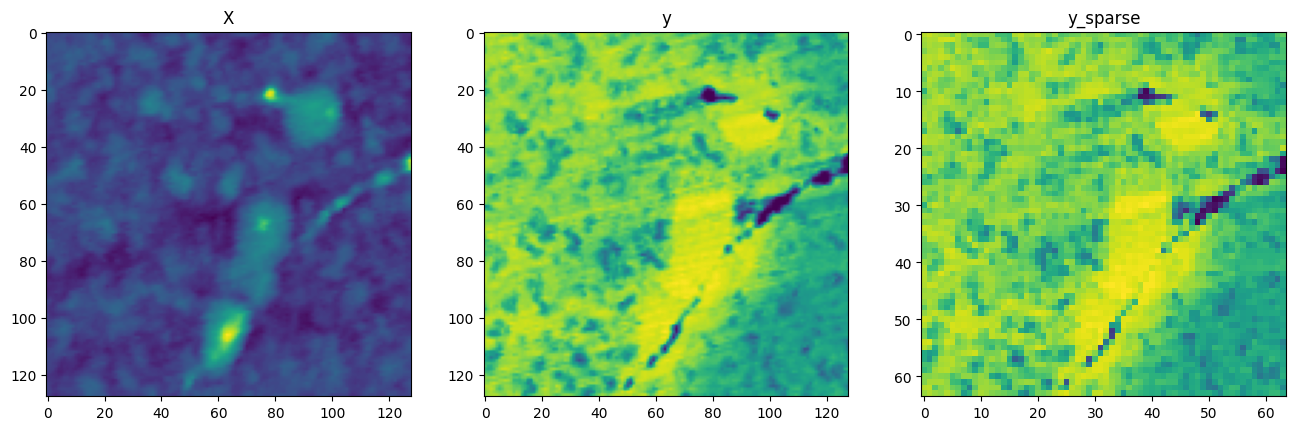

<Figure size 1920x1440 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))
fig = plt.figure(dpi=300)

X = item["X"]
y = item["y"]
y_sparse = item["y_sparse"]

ax1.imshow(X)
ax1.set_title("X")

ax2.imshow(y)
ax2.set_title("y")

ax3.imshow(y_sparse);
ax3.set_title("y_sparse");

plt.tight_layout()
plt.show();

In [13]:
from src.models.unet.unet import UNet

unet = UNet.get()

In [14]:
pred = unet(X.unsqueeze(0))

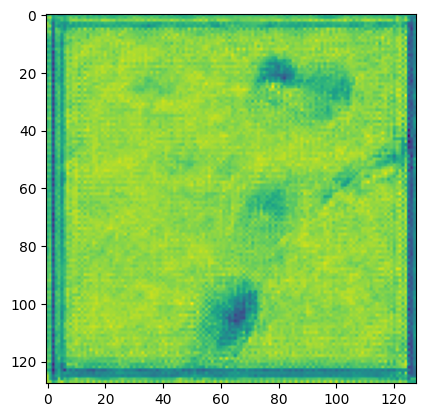

In [15]:
plt.imshow(pred.detach().squeeze().numpy())

In [ ]:
test_fp = "__weights__/2x/DS={all}-[X|y]-BS=32-opt=Adam-lr=1e-5_best.pth"
model = torch.load(test_fp)
model.apply(model._init_weights)

In [ ]:
model = SwinCAFM.swin_cafm_2x()